In [18]:
import os
import yaml
import psycopg2

import dbconfig as db

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

import urllib.request

In [19]:
config_file = "db_config.yaml"
db_config = db.load_db_config(db.load_config(config_file))

# Create connection
conn = db.create_connection(db_config)

In [20]:
# Query Functions
def gamerecap_selectbox_query(season: int):
    return f"""
            select distinct 
                game_id,
                old_game_id
            from "nflfastR_pbp"
            where season = {season}
            order by old_game_id desc
        """

# Example:
# pd.read_sql_query(gamerecap_selectbox_query(), conn)


def gamerecap_pbp_query(gameid: str):
    return f"""
            select *
            from "nflfastR_pbp"
            where game_id = "{gameid}"
            order by old_game_id, game_seconds_remaining desc
        """

# Example:
# (
#     pd.read_sql_query(gamerecap_pbp_query("2024_17_SEA_CHI"), conn).sort_values(
#         by=["play_id", "game_seconds_remaining"], ascending=[True, False]
#     )
# )

In [21]:
import requests
from PIL import Image
from io import BytesIO

import matplotlib.image as mpimg
import matplotlib.transforms as transforms

def get_team_color(
    team: str,
    conn: psycopg2.extensions.connection = conn,
) -> None:
    """
    Retrieves a team logo from the database based on the team and source.

    Args:
        team (str): The team abbreviation.
        source (str, optional): The source of the logo. Defaults to "espn".
        conn (psycopg2.extensions.connection): The database connection.

    Returns:
        str: The team color value.
    """
    query = f"""
        select team_color
        from "nflfastR_logos"
        where team_abbr = '{team.upper()}'
    """

    # print(f"Team: {team}")
    # print(query)

    df = pd.read_sql_query(
        sql=query,
        con=conn,
    )
    color = df[f"team_color"][0]

    return color

# Example:
# get_team_color("phi")


def get_image_from_url(
    url: str,
) -> Image:
    """
    Retrieves an image from a given URL.

    Args:
        url (str): The URL of the image.

    Returns:
        PIL.Image: The retrieved image object.
    """
    response = requests.get(url)
    return Image.open(BytesIO(response.content))


def get_team_logo(
    team: str,
    source: str = "espn",
    conn: psycopg2.extensions.connection = conn,
) -> None:
    """
    Retrieves a team logo from the database based on the team and source.

    Args:
        team (str): The team abbreviation.
        source (str, optional): The source of the logo. Defaults to "espn".
        conn (psycopg2.extensions.connection): The database connection.

    Returns:
        PIL.Image: The team logo image object.
    """
    query = f"""
        select team_logo_{source.lower()}
        from "nflfastR_logos"
        where team_abbr = '{team.upper()}'
    """

    # print(f"Team: {team}")
    # print(f"Source: {source}")
    # print(query)

    df = pd.read_sql_query(
        sql=query,
        con=conn,
    )
    url = df[f"team_logo_{source}"][0]

    return get_image_from_url(url=url)

# Example:
# get_team_logo("phi")

/var/folders/x7/xhgs2dv1471469zrfltg22l00000gn/T/ipykernel_94670/987541578.py:77: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(gamerecap_pbp_query(game_id), conn)
/var/folders/x7/xhgs2dv1471469zrfltg22l00000gn/T/ipykernel_94670/1864568951.py:32: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(
/var/folders/x7/xhgs2dv1471469zrfltg22l00000gn/T/ipykernel_94670/1864568951.py:32: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(
/var/folders/x7/xhgs2dv1471469zrfltg

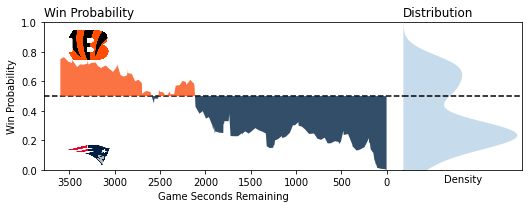

In [ ]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox


def plot_wp_dist(
    # df: pd.DataFrame,
    game_id: str,
) -> plt.figure:

    df = (pd.read_sql_query(gamerecap_pbp_query(game_id), conn),)

    wp = df["home_wp"].astype(float)

    # Create a density plot using Seaborn
    fig, ax = plt.subplots(figsize=(2, 4))
    sns.kdeplot(
        y=wp,
        ax=ax,
        fill=True,
    )

    ax.set_yticks([])
    ax.set_ylim(0, 1)
    ax.set_xlabel("Density")
    ax.set_ylabel("")
    ax.set_title("Win Probability Distribution", loc="left")
    return fig


# plot_wp_dist(
#     # df=pd.read_sql_query(gamerecap_pbp_query("2024_17_SEA_CHI"), conn),
#     game_id="2024_17_SEA_CHI",
# )


def plot_wp_worm(
    # df: pd.DataFrame,
    game_id: str,
) -> plt.figure:
    df = pd.read_sql_query(gamerecap_pbp_query(game_id), conn)

    df = df.query("qtr != 5")

    x = df["game_seconds_remaining"].astype(int)
    y = df["home_wp"].astype(float)

    # Create a density plot using Seaborn
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x, y)
    fig.gca().invert_xaxis()
    ax.set_ylim(0, 1)
    ax.set_xlabel("Game Seconds Remaining")
    ax.set_ylabel("Win Probability")
    ax.set_title("Win Probability", loc="left")
    return fig


# plot = plot_wp_worm(
#     # df=pd.read_sql_query(gamerecap_pbp_query("2024_17_ATL_WAS"), conn),
#     game_id="2024_17_ATL_WAS",
# )


def plot_wp(
    # df: pd.DataFrame,
    game_id: str,
) -> plt.figure:
    """
    Plots the win probability of a game.

    Args:
    game_id (str): The ID of the game.

    Returns:
    Tuple[plt.Figure, plt.Axes]: A tuple containing the figure and axes of the plot.
    """

    df = pd.read_sql_query(gamerecap_pbp_query(game_id), conn)
    # print(df.head())

    df = df.query("qtr != 5")

    x = df["game_seconds_remaining"].astype(int)
    y = df["vegas_home_wp"].astype(float)

    away_team = game_id.split("_")[2]
    home_team = game_id.split("_")[3]

    away_team_color = get_team_color(away_team)
    home_team_color = get_team_color(home_team)

    # Create mid-point for plot styling
    df["mid_wp"] = 0.5
    mid_wp = df["mid_wp"]

    # Create a density plot using Seaborn
    fig, ax = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(8, 3),
        gridspec_kw={
            "height_ratios": [1],
            "width_ratios": [3, 1],
            "wspace": 0,
            "hspace": 0,
        },
    )

    # Add Logos
    away_imagebox = OffsetImage(
        np.array(get_team_logo(away_team)),
        alpha=1,
        zoom=0.1,
    )
    away_ab = AnnotationBbox(
        away_imagebox,
        (3300, 0.15),
        frameon=False,
    )
    ax[0].add_artist(
        away_ab,
    )

    home_imagebox = OffsetImage(
        np.array(get_team_logo(home_team)),
        alpha=1,
        zoom=0.1,
    )
    home_ab = AnnotationBbox(
        home_imagebox,
        (3300, 0.85),
        frameon=False,
        clip_box=ax[0],
        clip_on=True,
    )
    ax[0].add_artist(
        home_ab,
    )

    # ax[0].plot(x, y, zorder=1)
    ax[0].axhline(0.5, color="black", linestyle="--")
    ax[0].fill_between(
        x,
        y,
        mid_wp,
        where=y >= mid_wp,
        interpolate=True,
        facecolor=home_team_color,
        alpha=0.8,
        zorder=3,
    )
    ax[0].fill_between(
        x,
        y,
        mid_wp,
        where=y <= mid_wp,
        interpolate=True,
        facecolor=away_team_color,
        alpha=0.8,
        zorder=3,
    )
    ax[0].invert_xaxis()
    ax[0].set_ylim(0, 1)
    ax[0].set_xlabel("Game Seconds Remaining")
    ax[0].set_ylabel("Win Probability")
    ax[0].set_title("Win Probability", loc="left")

    # Density Plot
    sns.kdeplot(
        y=y,
        ax=ax[1],
        fill=True,
        linewidth=0,
    )
    ax[1].axhline(0.5, color="black", linestyle="--")

    # ax[1].spines["top"].set_visible(False)
    # ax[1].spines["right'].set_visible(False)
    # ax[1].spines['bottom'].set_visible(False)
    ax[1].spines["left"].set_visible(False)

    ax[1].set_xticks([])
    ax[1].set_yticks([])
    ax[1].set_ylim(0, 1)
    ax[1].set_xlabel("Density")
    ax[1].set_ylabel("", labelpad=20)
    ax[1].set_title("Distribution", loc="left")

    fig.tight_layout()

    return fig


plot = plot_wp(
    game_id="2024_01_NE_CIN",
)

In [ ]:
def plot_ep(
    # df: pd.DataFrame,
    game_id: str,
) -> plt.figure:
    """
    Plots the win probability of a game.

    Args:
    game_id (str): The ID of the game.

    Returns:
    Tuple[plt.Figure, plt.Axes]: A tuple containing the figure and axes of the plot.
    """

    df = pd.read_sql_query(gamerecap_pbp_query(game_id), conn)
    # print(df.head())

    df = df.query("qtr != 5")

    x = df["game_seconds_remaining"].astype(int)
    y = df["ep"].astype(float)

    away_team = game_id.split("_")[2]
    home_team = game_id.split("_")[3]

    away_team_color = get_team_color(away_team)
    home_team_color = get_team_color(home_team)

    # Create a density plot using Seaborn
    fig, ax = plt.subplots(
        nrows=1,
        ncols=2,
        figsize=(8, 3),
        gridspec_kw={
            "height_ratios": [1],
            "width_ratios": [3, 1],
            "wspace": 0,
            "hspace": 0,
        },
    )

    # Add Logos
    away_imagebox = OffsetImage(
        np.array(get_team_logo(away_team)),
        alpha=1,
        zoom=0.1,
    )
    away_ab = AnnotationBbox(
        away_imagebox,
        (3300, 0.15),
        frameon=False,
    )
    ax[0].add_artist(
        away_ab,
    )

    home_imagebox = OffsetImage(
        np.array(get_team_logo(home_team)),
        alpha=1,
        zoom=0.1,
    )
    home_ab = AnnotationBbox(
        home_imagebox,
        (3300, 0.85),
        frameon=False,
        clip_box=ax[0],
        clip_on=True,
    )
    ax[0].add_artist(
        home_ab,
    )

    # ax[0].plot(x, y, zorder=1)
    ax[0].axhline(0.5, color="black", linestyle="--")
    ax[0].plot(
        x,
        y,
        where=y >= mid_wp,
        interpolate=True,
        facecolor=home_team_color,
        alpha=0.8,
        zorder=3,
    )
    ax[0].fill_between(
        x,
        y,
        where=y <= mid_wp,
        interpolate=True,
        facecolor=away_team_color,
        alpha=0.8,
        zorder=3,
    )
    ax[0].invert_xaxis()
    ax[0].set_ylim(0, 1)
    ax[0].set_xlabel("Game Seconds Remaining")
    ax[0].set_ylabel("Win Probability")
    ax[0].set_title("Win Probability", loc="left")

    # Density Plot
    sns.kdeplot(
        y=y,
        ax=ax[1],
        fill=True,
        linewidth=0,
    )
    ax[1].axhline(0.5, color="black", linestyle="--")

    # ax[1].spines['top'].set_visible(False)
    # ax[1].spines['right'].set_visible(False)
    # ax[1].spines['bottom'].set_visible(False)
    ax[1].spines["left"].set_visible(False)

    ax[1].set_xticks([])
    ax[1].set_yticks([])
    ax[1].set_ylim(0, 1)
    ax[1].set_xlabel("Density")
    ax[1].set_ylabel("", labelpad=20)
    ax[1].set_title("Distribution", loc="left")

    fig.tight_layout()

    return fig


plot = plot_wp(
    game_id="2024_01_NE_CIN",
)

In [65]:
df = pd.read_sql_query(gamerecap_pbp_query("2024_18_WAS_DAL"), conn)

df.groupby("passer_player_name").apply(lambda x: pd.Series({
    "plays": (x["qb_dropback"] == 1).sum(),
    "epa/play": (x["epa"].sum() / (x["qb_dropback"] == 1).sum()).round(2),
    "total_epa": x["epa"].sum().round(2),
    "iay": x["air_yards"].mean().round(2),
    "cay": x.loc[x["complete_pass"] == 1, "air_yards"].mean().round(2),
    "cp": (x["complete_pass"].sum() / (x["qb_dropback"] == 1).sum()).round(3)*100,
    "xcp": x["cp"].mean().round(3)*100,
    "cpoe": (x["complete_pass"].sum() / (x["qb_dropback"] == 1).sum()).round(3)*100 - x["cp"].mean().round(3)*100,
})).reset_index()

/var/folders/x7/xhgs2dv1471469zrfltg22l00000gn/T/ipykernel_94670/618769831.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(gamerecap_pbp_query("2024_18_WAS_DAL"), conn)


AttributeError: 'float' object has no attribute 'round'

In [232]:
from subprocess import run

def convert_svg_to_png(svg_file, png_file):
    """
    Convert an SVG file to a PNG file using ImageMagick.
    
    Args:
        svg_file (str): The path to the input SVG file.
        png_file (str): The path to the output PNG file.
    """
    command = f"convert {svg_file} -background none {png_file}"
    run(command, shell=True)

# Example usage:
svg_file = "input.svg"
png_file = "output.png"

fpath = "assets/logos/svg/"

for i in os.listdir(fpath):
    filename = os.path.splitext(i)[0]
    convert_svg_to_png(
        svg_file=f"{fpath}/{i}",
        png_file=f"assets/logos/png/{filename}.png",
    )

Team: min
Source: espn

        select team_logo_espn
        from "nflfastR_logos"
        where team_abbr = 'MIN'
    
Team: phi
Source: espn

        select team_logo_espn
        from "nflfastR_logos"
        where team_abbr = 'PHI'
    


/var/folders/x7/xhgs2dv1471469zrfltg22l00000gn/T/ipykernel_57143/1903381485.py:45: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(
/var/folders/x7/xhgs2dv1471469zrfltg22l00000gn/T/ipykernel_57143/1903381485.py:45: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(


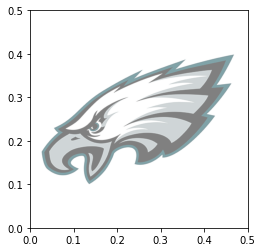

In [329]:
def plot_logos(
    home_image: Image,
    away_image: Image,
):
    # Convert the PIL Image to a numpy array
    home_image_array = np.array(home_image)
    away_image_array = np.array(away_image)

    # Create a Matplotlib figure and axis
    fig, ax = plt.subplots()

    # Display the image on the axis
    ax.imshow(
        home_image_array,
        extent=[0, 0.5, 0.5, 1],  # [left, right, bottom, top]
        alpha=0.5,
    )

    ax.imshow(
        away_image_array,
        extent=[0, 0.5, 0, 0.5],
        alpha=0.5,
    )

    # Shrink the image to 50% the size of the plot
    # scale = transforms.Affine2D().scale(0.5, 0.5)
    # home_im.set_transform(home_im.get_transform() + scale)
    # away_im.set_transform(away_im.get_transform() + scale)

    # Show the plot
    plt.show()


plot_logos(home_image=get_team_logo("min"), away_image=get_team_logo("phi"))